In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pystout import pystout


In [23]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/DataCollection130052025/all_apps_wide-2025-05-14.csv")



In [24]:
df_two_sided = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/two_sided_without_TA.pkl")

## First Mover Regression

<Axes: >

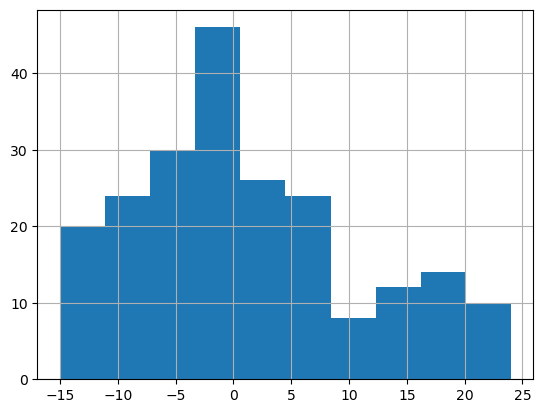

In [25]:
df_two_sided["gains_from_trade"].hist()

In [26]:
df_regression = df_two_sided.dropna(subset=["payoff", "first_offer"])

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

model_1 = smf.ols(formula='payoff ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                 0.0002500
Date:                Tue, 10 Jun 2025   Prob (F-statistic):              0.987
Time:                        14:11:10   Log-Likelihood:                -553.18
No. Observations:                 188   AIC:                             1110.
Df Residuals:                     186   BIC:                             1117.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.1277      0.476      4.472      

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_5991/536089823.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')


In [27]:
df_regression = df_two_sided[df_two_sided["split_gains_from_trade"] > 0]

df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce') 

df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)

model_2 = smf.ols(formula='split_gains_from_trade ~ first_offer', data=df_regression).fit()

# 4. Examine the results
print(model_2.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.047
Model:                                OLS   Adj. R-squared:                  0.030
Method:                     Least Squares   F-statistic:                     2.781
Date:                    Tue, 10 Jun 2025   Prob (F-statistic):              0.101
Time:                            14:11:10   Log-Likelihood:                -59.368
No. Observations:                      59   AIC:                             122.7
Df Residuals:                          57   BIC:                             126.9
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_5991/3190619071.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression["payoff"] = pd.to_numeric(df_regression["payoff"], errors='coerce')
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_5991/3190619071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regression.dropna(subset=["split_gains_from_trade", "first_offer"], inplace=True)


In [29]:

model_3 = smf.ols(formula='bargaining_time_full_sec ~ valuation', data=df_two_sided).fit()

print(model_3.summary())

                               OLS Regression Results                               
Dep. Variable:     bargaining_time_full_sec   R-squared:                       0.142
Model:                                  OLS   Adj. R-squared:                  0.002
Method:                       Least Squares   F-statistic:                     1.011
Date:                      Tue, 10 Jun 2025   Prob (F-statistic):              0.457
Time:                              14:11:37   Log-Likelihood:                -4669.9
No. Observations:                       214   AIC:                             9402.
Df Residuals:                           183   BIC:                             9506.
Df Model:                                30                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [18]:
pystout(models=[model_1, model_2],
        file='test_table.tex',
        addnotes=['Here is a little note','And another one'],
        digits=2,
        endog_names=['Payoff','Split Gains from Trade'],
        varlabels={'const':'Constant','first_offer':'First Offer'},
        modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}
        )


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_5991/4137003316.py:7: SyntaxWarning: invalid escape sequence '\s'
  modstat={'nobs':'Obs','rsquared_adj':'Adj. R\sym{2}'}


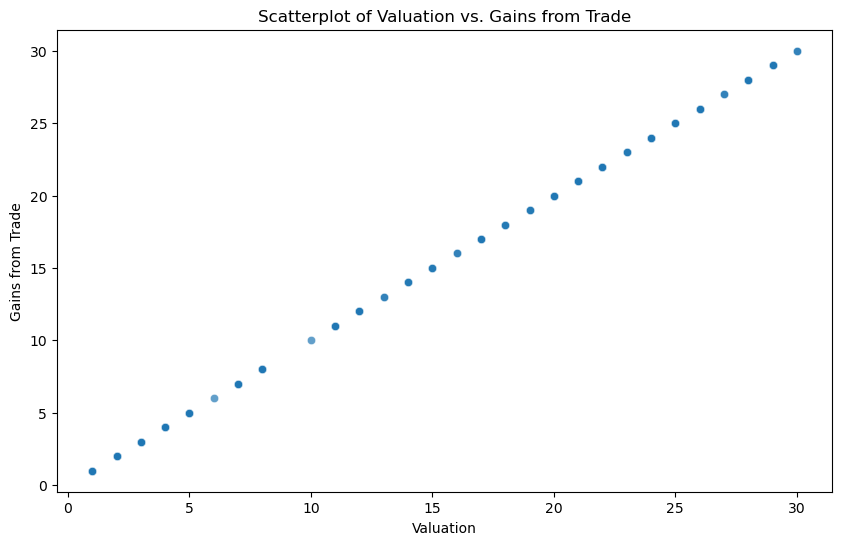

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='valuation', y='gains_from_trade', data=df_buyers, alpha=0.7)

# Customize the plot
plt.title('Scatterplot of Valuation vs. Gains from Trade')
plt.xlabel('Valuation')
plt.ylabel('Gains from Trade')

# Show the plot
plt.show()


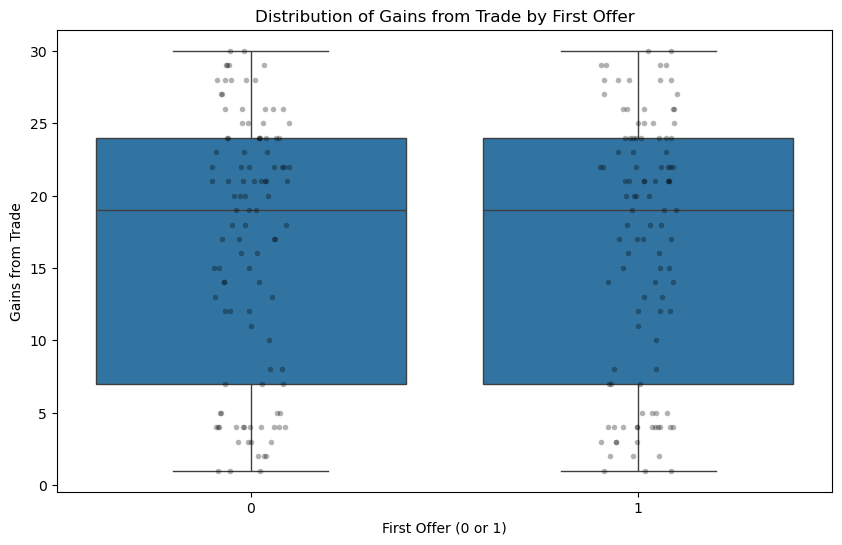

In [6]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='first_offer', y='gains_from_trade', data=df)

# Customize the plot
plt.title('Distribution of Gains from Trade by First Offer')
plt.xlabel('First Offer (0 or 1)')
plt.ylabel('Gains from Trade')

# Add individual data points
sns.stripplot(x='first_offer', y='gains_from_trade', data=df, 
              color='black', alpha=0.3, size=4)

# Save the plot
plt.show()

In [ ]:
df = pd.read_pickle("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/one_sided_with_TA.pkl")
df_buyers = df[(df["participant_role"] == "Buyer")]

In [3]:
# Define the piecewise function
def equilibrium_payoff(x, c=0.05, r=0.01):
    if x <= 7.72:
        return 0
    elif x >= 21.40:
        return x/2
    else:
        b = x
        return ((r*b + 2*c)/(r*21.40 + 2*c)) * (b/2 + c/r) - c/r


In [4]:
# Generate x values for the theoretical line
x_values = np.linspace(0, 30, 1000)
y_values = [equilibrium_payoff(x) for x in x_values]


COLOR_SCHEME=["#3c5488","#00a087", "#e64b35", "#4dbbd5",  "#f39b7f", ]
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
sns.set_style("white")
sns.set_palette(COLOR_SCHEME)


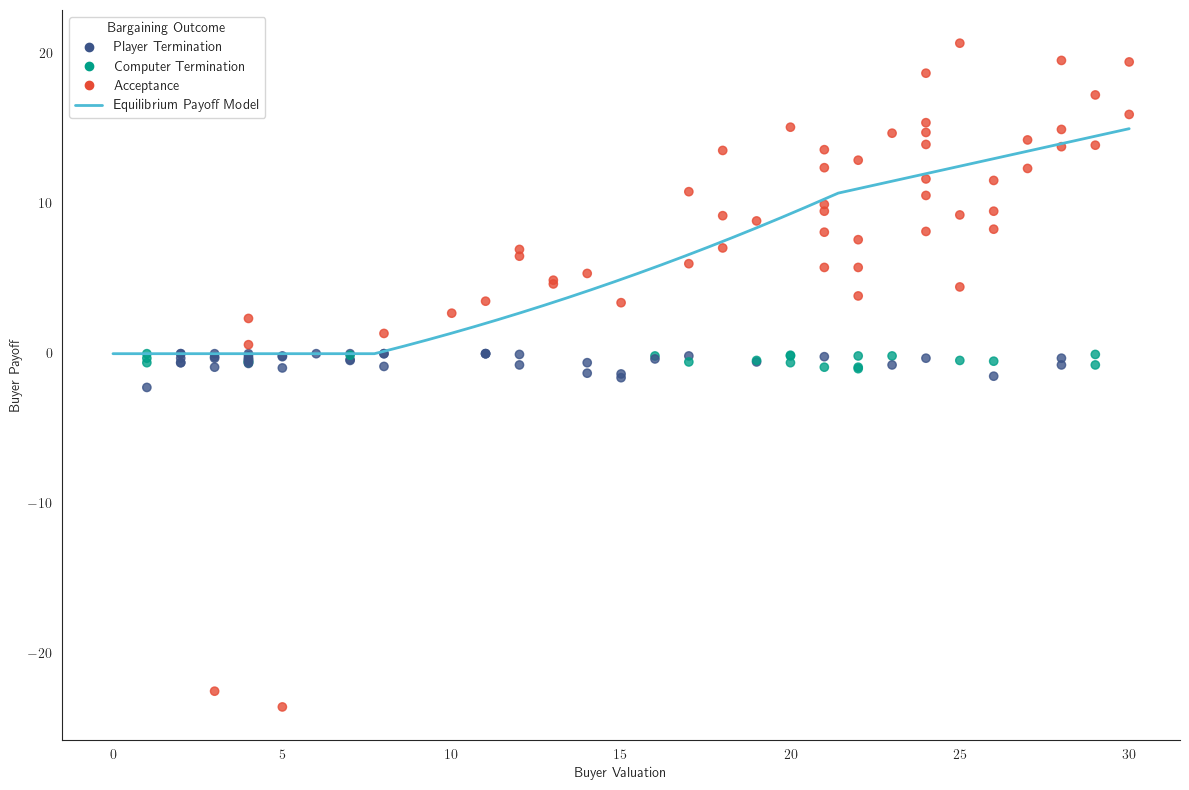

In [9]:

# Define your color scheme
COLOR_SCHEME = ["#3c5488", "#00a087", "#e64b35", "#4dbbd5", "#f39b7f"]

# Define a mapping from outcome labels to colors
outcome_color_map = {
    'Player': COLOR_SCHEME[0],               # Player Termination
    'Random_Termination': COLOR_SCHEME[1],   # Computer Termination
    'acceptance': COLOR_SCHEME[2],           # Highlight Acceptance
}

# Assign color values based on the outcome
colors = df_buyers['bargaining_outcome'].map(outcome_color_map)

plt.figure(figsize=(12, 8))

# Plot the theoretical line
plt.plot(x_values, y_values, color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')

# Add the scatter plot with custom colors
scatter = plt.scatter(
    df_buyers['valuation'],
    df_buyers['payoff'],
    c=colors,
    alpha=0.8
)

plt.xlabel('Buyer Valuation (Equals Surplus) ')
plt.ylabel('Buyer Payoff')

# Create custom legend
import matplotlib.lines as mlines
legend_elements = [
    mlines.Line2D([], [], color=COLOR_SCHEME[0], marker='o', linestyle='None', label='Player Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[1], marker='o', linestyle='None', label='Computer Termination'),
    mlines.Line2D([], [], color=COLOR_SCHEME[2], marker='o', linestyle='None', label='Acceptance'),
    mlines.Line2D([], [], color=COLOR_SCHEME[3], linewidth=2, label='Equilibrium Payoff Model')
]

plt.legend(handles=legend_elements, title="Bargaining Outcome")

sns.despine()
plt.tight_layout()
plt.show()
